In [1]:
import pandas as pd

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

X=pd.read_csv("../data/X.csv")
y=pd.read_csv("../data/y.csv").squeeze()

In [2]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


import matplotlib.pyplot as plt

In [3]:
scale=StandardScaler()
X_train=scale.fit_transform(X_train)
X_test=scale.transform(X_test)

In [4]:
model_logisticregression = LogisticRegression()
model_logisticregression.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
y_pred = model_logisticregression.predict(X_test)
y_prob = model_logisticregression.predict_proba(X_test)[:, 1]

In [6]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_prob)
print("accuracy: ",accuracy)
print("precision: ",precision)
print("recall: ",recall)
print("f1: ",f1)
print("roc_auc: ",roc_auc)

accuracy:  0.7222509034589571
precision:  0.7394886363636364
recall:  0.94243301955105
f1:  0.8287169691181152
roc_auc:  0.7672450562359671


In [7]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.55      0.18      0.27      1112
           1       0.74      0.94      0.83      2762

    accuracy                           0.72      3874
   macro avg       0.65      0.56      0.55      3874
weighted avg       0.69      0.72      0.67      3874



In [8]:
y_train.value_counts()

Result
1    11049
0     4445
Name: count, dtype: int64

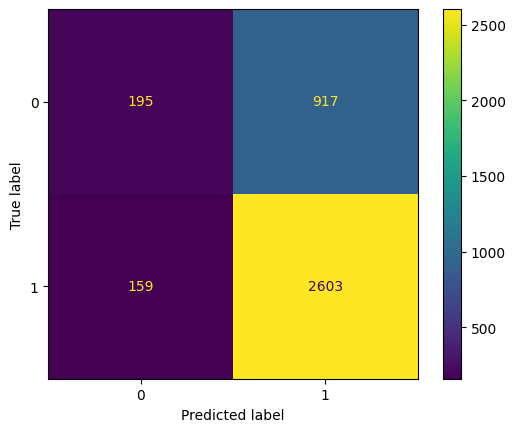

True Negatives:  195
False Positives:  917
False Negatives:  159
True Positives:  2603


In [9]:

cm = confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_logisticregression.classes_)
dis.plot()
plt.show()
tn, fp, fn, tp = cm.ravel()
print("True Negatives: ",tn)
print("False Positives: ",fp)
print("False Negatives: ",fn)
print("True Positives: ",tp)


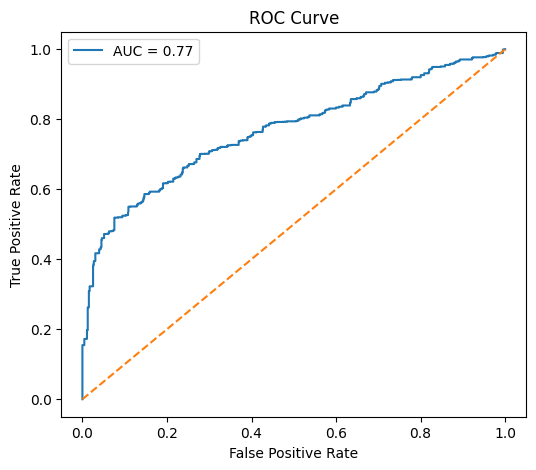

In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [11]:
train_accuracy = model_logisticregression.score(X_train, y_train)
test_accuracy = model_logisticregression.score(X_test, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.7240222021427649
Test Accuracy: 0.7222509034589571


In [12]:

results = pd.DataFrame({
    "Model": ["logistic regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})

results.to_csv("../results/logisticregression_results.csv", index=False)
report=classification_report(y_test,y_pred,output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../results/logisticregression_classification_report.csv"
)